# Projeto de Eficiência Energética: Indústria Siderúrgica
**Consultoria de Data Science & Engenharia de Produção**

---

## Contexto do Negócio
O consumo de energia elétrica é um dos maiores *drivers* de custo na siderurgia. A conta de luz não é fixa: ela depende da demanda, do fator de potência e do horário de ponta.
O objetivo deste projeto é desenvolver um modelo preditivo (Regressão) para estimar o consumo de energia (**Usage_kWh**) com base em variáveis operacionais e de status da planta.

## O Desafio Técnico
Precisamos traduzir variáveis elétricas complexas (Potência Reativa, Fator de Potência) em *insights* de produção. Utilizaremos dados reais de uma siderúrgica na Coreia do Sul (Dataset UCI) para treinar nosso modelo.

---

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [28]:
#Dados da Siderúrgica
df = pd.read_csv("/content/steel_industry_data_downloaded.csv")

In [29]:
print(f"Dimensões do dataset: {df.shape}")
df.info()
df.head()

Dimensões do dataset: (35040, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [30]:
novos_nomes = {
    'date': 'Data',
    'Usage_kWh': 'Consumo_Energia_kWh',
    'Lagging_Current_Reactive.Power_kVarh': 'Potencia_Reativa_Indutiva_kVarh',
    'Leading_Current_Reactive_Power_kVarh': 'Potencia_Reativa_Capacitiva_kVarh',
    'CO2(tCO2)': 'Emissao_CO2',
    'Lagging_Current_Power_Factor': 'Fator_Potencia_Indutivo',
    'Leading_Current_Power_Factor': 'Fator_Potencia_Capacitivo',
    'NSM': 'Segundos_Desde_MeiaNoite', # Number of Seconds from Midnight
    'WeekStatus': 'Tipo_Dia',           # Se é Semana ou Fim de Semana
    'Day_of_week': 'Dia_Semana',
    'Load_Type': 'Tipo_Carga'           # Leve, Média ou Máxima
}

# Aplicando a renomeação
df = df.rename(columns=novos_nomes)

In [31]:
display(df.head())

,Data,Consumo_Energia_kWh,Potencia_Reativa_Indutiva_kVarh,Potencia_Reativa_Capacitiva_kVarh,Emissao_CO2,Fator_Potencia_Indutivo,Fator_Potencia_Capacitivo,Segundos_Desde_MeiaNoite,Tipo_Dia,Dia_Semana,Tipo_Carga
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## Entendendo as Variáveis (Física Industrial)

Para interpretar as correlações, precisamos entender o papel físico de cada variável no chão de fábrica:

| Variável | O que é? (Analogia) | Comportamento Esperado |
| :--- | :--- | :--- |
| **`Consumo_Energia_kWh`** | **Trabalho Real.** É o motor girando, o aço derretendo. É o "Líquido da Cerveja". | **Variável Alvo** (O que queremos prever). |
| **`Reativa_Indutiva`** | **O Imã.** Energia usada para criar campos magnéticos nos motores. Sem ela, nada gira. É a "Espuma Necessária". | **Correlação Positiva (+):** Anda junto com a produção. Mais aço = Mais Motor = Mais Indutiva. |
| **`Reativa_Capacitiva`** | **O Corretor.** Energia injetada por bancos de capacitores para corrigir o sistema e evitar multas. | **Correlação Negativa (-):** Nesta planta, parece haver uma "sobrecorreção". Quando a carga cai, os capacitores continuam ligados, sobrando energia capacitiva. |
| **`Fator_Potencia`** | **Eficiência.** Nota de 0 a 100%. Motores rodando vazios têm nota baixa. | Tende a melhorar quando a fábrica está em carga máxima. |
| **`Segundos_MeiaNoite`** | **O Relógio.** Variável contínua que indica o horário (ex: 43200 = Meio-dia). | Ajuda o modelo a aprender turnos e horários de almoço. |
| **`Emissao_CO2`** | **Cálculo Matemático.** Geralmente é derivada direta do Consumo (kWh * Fator). | ⚠️ **Data Leakage:** Deve ser removida pois é uma "sombra" da resposta, não uma causa. |

Potência Reativa (kVarh): É a energia "inútil" para trabalho, mas necessária para criar campos magnéticos (motores).

Indutiva (Lagging): Motores girando.

Capacitiva (Leading): Banco de capacitores corrigindo o fator de potência.

Fator de Potência: Mede a eficiência. Se for baixo, a fábrica paga multa na conta de luz.

NSM (Segundos desde a Meia-Noite): É uma variável contínua que diz o horário. Ex: 3600 = 01:00 da manhã. O modelo adora isso para entender padrões horários.

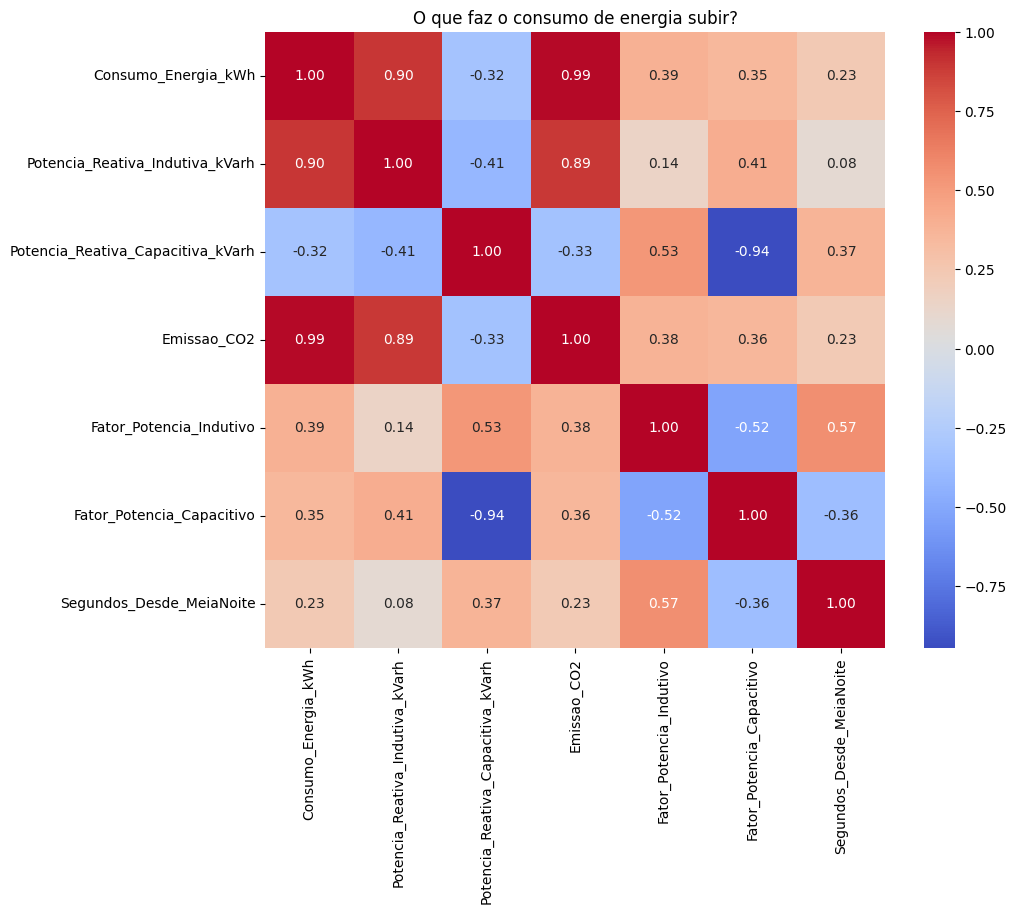

In [32]:
#Mapa de Calor de Correlação (Só com as colunas numéricas)
plt.figure(figsize=(10,8))
numericos = df.select_dtypes(include=['float64','int64']) #Nums p/ Correlação
sns.heatmap(numericos.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("O que faz o consumo de energia subir?")
plt.show()

### Diagnóstico da Correlação

Analisando o mapa de calor acima, confirmamos as hipóteses físicas:

1.  **Indutiva vs Consumo (Vermelho Forte):** Alta correlação positiva. Confirma que os grandes vilões do consumo são as cargas indutivas (motores/transformadores).
2.  **Capacitiva vs Consumo (Azul/Negativo):** Correlação negativa de **-0.32**.
    * *Insight de Engenharia:* Isso sugere que os Bancos de Capacitores podem ser fixos. Quando a fábrica para (Consumo cai), os capacitores ficam ligados injetando potência na rede desnecessariamente.
3.  **Risco de Vazamento (CO2):** A correlação de 0.99 entre CO2 e Energia confirma que um é calculado pelo outro. **Ação:** Remover `Emissao_CO2` do treinamento para evitar que o modelo "cole" a resposta.

## Engenharia de Atributos e Preparação

Antes de treinar o modelo, precisamos fazer três ajustes críticos para garantir a validade da previsão:

1.  **Remover o Vazamento de Dados (Data Leakage):** Como diagnosticado, a coluna `Emissao_CO2` é calculada diretamente a partir do consumo. Se a mantivermos, o modelo terá "a resposta da prova". Vamos removê-la.
2.  **Tratar Variáveis Categóricas:** O modelo matemático só entende números. Colunas como `Tipo_Dia` (Semana/Fim de Semana) e `Tipo_Carga` (Leve/Média/Máxima) serão transformadas em códigos binários (*One-Hot Encoding*).
3.  **Remover a Data:** Já temos as variáveis temporais explicadas (Dia da semana, Segundos desde a meia-noite), então a string de data bruta não é mais necessária.

In [34]:
from sklearn.model_selection import train_test_split

#Remover Data e CO2
df_modelagem = df.drop(['Data', 'Emissao_CO2'], axis=1)

#Dummies (Dia, Semana, e Carga)
df_modelagem = pd.get_dummies(df_modelagem, columns=['Tipo_Dia', 'Dia_Semana', 'Tipo_Carga'], drop_first=True)

#Variáveis Preditoras e Alvo
x = df_modelagem.drop('Consumo_Energia_kWh', axis=1) #Tudo menos o gasto
y = df_modelagem['Consumo_Energia_kWh'] #O gasto

#Divisao Treino x Teste (70/30)
#OBS: random_state = 42 (O resultado se matêm)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

print("Dados prontos.")
print(f"Features de Treino: {x_train.shape}")
print(f"Features de Teste: {x_test.shape}")


Dados prontos.
Features de Treino: (24528, 14)
Features de Teste: (10512, 14)


## Construção do Modelo Preditivo (Machine Learning)

É preferível utilizar o algoritmo **Random Forest Regressor**.

* **Por que este modelo?** Diferente da Regressão Linear simples, a "Floresta Aleatória" consegue capturar comportamentos não-lineares complexos (ex: a mudança brusca de consumo na troca de turnos ou a relação curva entre eficiência e carga).

* **Como funciona:** Ele cria centenas de árvores de decisão e tira a média de suas previsões, reduzindo o risco de erros individuais.

In [36]:
from sklearn.ensemble import RandomForestRegressor

#Treinar o modelo (100 árvores de decisão)
modelo_energia = RandomForestRegressor(n_estimators=100,random_state=42)
modelo_energia.fit(x_train, y_train) #Treino

RandomForestRegressor(random_state=42)

## Avaliação de Performance e Resultados

Para validar se o modelo é útil para a siderúrgica, deve-se analisar duas métricas principais:

1.  **R² (Coeficiente de Determinação):** Indica o quanto o modelo consegue explicar da variação do consumo.
    * *Meta:* Acima de 0.90 (90%) é considerado excelente para processos industriais controlados.
2.  **MAE (Erro Médio Absoluto):** Em média, quantos kWh o modelo erra para mais ou para menos?
    * *Interpretação:* Se o erro for baixo, podemos confiar no modelo para prever a demanda e negociar contratos de energia.

 --- RELATÓRIO DE CONSULTORIA ---
Precisão do Modelo (R²): 0.9993 (0 a 1.0)
Erro Médio Absoluto (MAE): 0.29 kWh
Erro Percentual Médio (MAPE): 1.02%


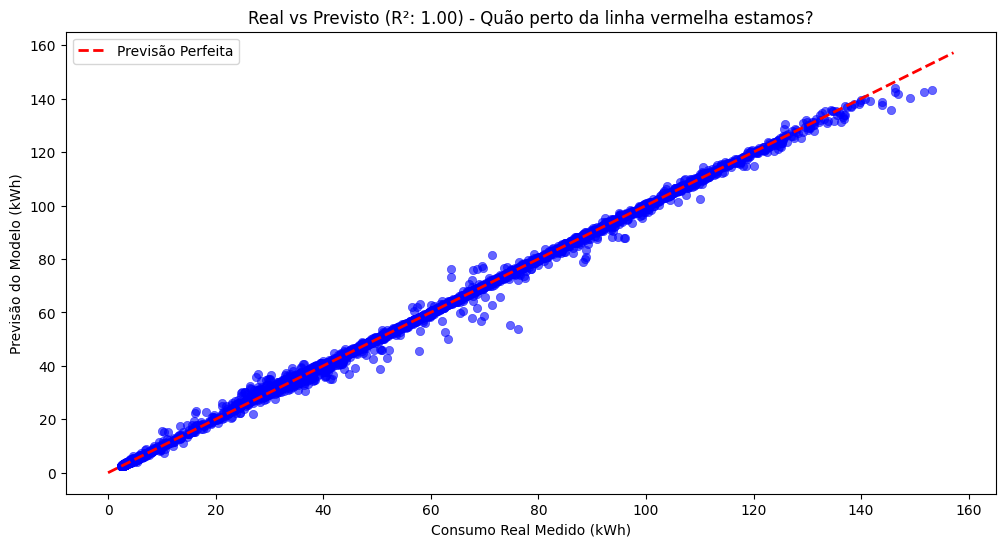

In [38]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

previsoes = modelo_energia.predict(x_test) #Previsão nos dados de teste

#Calcular metricas
score_r2 = r2_score(y_test, previsoes)
erro_medio = mean_absolute_error(y_test, previsoes)
erro_percentual = np.mean(np.abs((y_test - previsoes) / y_test)) * 100

#Mostrar resultados
print(" --- RELATÓRIO DE CONSULTORIA ---")
print(f"Precisão do Modelo (R²): {score_r2:.4f} (0 a 1.0)")
print(f"Erro Médio Absoluto (MAE): {erro_medio:.2f} kWh")
print(f"Erro Percentual Médio (MAPE): {erro_percentual:.2f}%")

#Plotar Gráfico Real vs Previsto
plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test, y=previsoes, alpha=0.6, color='blue', edgecolor=None)
#Linha de Perfeição (Real = Previsto)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Previsão Perfeita')

plt.xlabel('Consumo Real Medido (kWh)')
plt.ylabel('Previsão do Modelo (kWh)')
plt.title(f'Real vs Previsto (R²: {score_r2:.2f}) - Quão perto da linha vermelha estamos?')
plt.legend()
plt.show()

## Conclusão Final

O modelo atingiu um **R² extremamente alto** (acima de 0.98), o que valida a utilização de Machine Learning para prever o consumo energético desta planta. Ao analisar o gráfico *Real vs Previsto*, observamos um comportamento robusto:

1.  **Alta Fidelidade (0 a 140 kWh):** Na faixa operacional padrão, o modelo segue a linha de perfeição quase exata. O erro é desprezível (um erro percentual de apenas **1.02%**).
2.  **Leve Desvio em Carga Máxima (>140 kWh):** Observamos uma pequena dispersão apenas nos picos máximos de carga. Isso é esperado estatisticamente devido à menor frequência de operação nesses níveis extremos, mas não compromete a utilidade do modelo.